In [10]:
%nsys enable

Nsight Systems is now enabled. Restart the kernel to apply the changes.


In [1]:
import masknmf
import torch
import cupy
import numpy as np

Unable to find extension: VK_EXT_physical_device_drm


Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x007\x08\x06\x00\x00\x00\xb6\x1bw\x99\x…

Valid,Device,Type,Backend,Driver
✅ (default),AMD Radeon RX 570 Series (RADV POLARIS10),DiscreteGPU,Vulkan,Mesa 22.3.6
✅,NVIDIA GeForce RTX 3080,DiscreteGPU,Vulkan,590.44.01
❗ limited,"llvmpipe (LLVM 15.0.6, 256 bits)",CPU,Vulkan,Mesa 22.3.6 (LLVM 15.0.6)
❌,"AMD Radeon RX 570 Series (polaris10, LLVM 15.0.6, DRM 3.49, 6.1.0-41-amd64)",Unknown,OpenGL,4.6 (Core Profile) Mesa 22.3.6


pygfx version from git (0.9.0) and __version__ (0.16.0) don't match.
To silence this warning, use a fully namespaced name.


In [19]:
dmr = masknmf.DemixingResults.from_hdf5("/home/kushal/data/alyx/cortexlab/Subjects/SP058/2024-07-18/demix.hdf5")

In [20]:
dmr.to("cuda")

In [4]:
%load_ext line_profiler

In [21]:
%lprun -f dmr.fluctuating_background_array.getitem_tensor dmr.fluctuating_background_array[15498]

Timer unit: 1e-09 s

Total time: 0.000399441 s
File: /home/kushal/repos/masknmf-toolbox/masknmf/demixing/demixing_arrays/fluctuating_background_array.py
Function: FluctuatingBackgroundArray.getitem_tensor at line 94

Line #      Hits         Time  Per Hit   % Time  Line Contents
    94                                               def getitem_tensor(
    95                                                   self,
    96                                                   item: Union[int, list, np.ndarray, Tuple[Union[int, np.ndarray, slice, range]]],
    97                                               ):
    98         1       6234.0   6234.0      1.6          frame_indexer, item = self._parse_indices(item)
    99                                           
   100                                                   # Step 3: Now slice the data with frame_indexer (careful: if the ndims has shrunk, add a dim)
   101         1      20614.0  20614.0      5.2          b_crop = self.b[:, frame_in

In [10]:
%lprun -f dmr.pmd_array.getitem_tensor dmr.pmd_array[4875]

Timer unit: 1e-09 s

Total time: 0.000221454 s
File: /home/kushal/repos/masknmf-toolbox/masknmf/compression/pmd_array.py
Function: PMDArray.getitem_tensor at line 284

Line #      Hits         Time  Per Hit   % Time  Line Contents
   284                                               def getitem_tensor(
   285                                                   self,
   286                                                   item: Union[int, list, np.ndarray, Tuple[Union[int, np.ndarray, slice, range]]],
   287                                               ) -> torch.tensor:
   288         1       8357.0   8357.0      3.8          frame_indexer, item = self._parse_indices(item)
   289                                           
   290                                                   # Step 3: Now slice the data with frame_indexer (careful: if the ndims has shrunk, add a dim)
   291         1      15040.0  15040.0      6.8          v_crop = self._v[:, frame_indexer]
   292         1       17

In [4]:
%%timeit
np.random.randint(0, dmr.num_frames)

1.56 μs ± 13.3 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [39]:
%%timeit -n 1 -r 1
sparse_stream = torch.cuda.Stream()
with torch.cuda.stream(sparse_stream):
    dmr.fluctuating_background_array[np.random.randint(0, dmr.num_frames)]

# torch.cuda.current_stream().wait_stream(sparse_stream)

18.7 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [65]:
%%timeit -n 1 -r 1
dmr.fluctuating_background_array[np.random.randint(0, dmr.num_frames)]

17.5 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [5]:
u = dmr.fluctuating_background_array.u.to_sparse_coo().coalesce().to_sparse_csr()
a = dmr.fluctuating_background_array.a

/home/kushal/repos/masknmf-toolbox/masknmf/demixing/demixing_arrays/fluctuating_background_array.py:36: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  self._u = u.to_sparse_csr()


In [131]:
sparse_stream = torch.cuda.Stream()

In [76]:
# %%timeit -n 1 -r 1
index = 1
b_crop = dmr.fluctuating_background_array.b[:, index].unsqueeze(1)

u_crop = u

# with torch.cuda.stream(sparse_stream):
product = torch.matmul(a, b_crop)
final0 = torch.sparse.mm(u_crop, product)

In [77]:
final0.shape

torch.Size([262144, 1])

In [137]:
index = np.random.randint(0, dmr.num_frames)
b_crop = dmr.fluctuating_background_array.b[:, index].unsqueeze(1)

In [177]:
%%timeit -n 1 -r 1
ab = torch.matmul(a, b_crop)

coo = u_crop.to_sparse_coo().coalesce()
rows = coo.indices()[0]
cols = coo.indices()[1]
vals = coo.values()

weighted = vals.unsqueeze(1) * ab[cols]

out = torch.zeros(u_crop.shape[0], rhs.shape[1], device=ab.device, dtype=ab.dtype)
out.scatter_add_(0, rows.unsqueeze(1).expand_as(weighted), weighted)

876 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [179]:
type(a)

torch.Tensor

In [ ]:
out.coalesce

In [182]:
u_crop.co

AcceleratorError: CUDA error: unspecified launch failure
Search for `cudaErrorLaunchFailure' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [178]:
type(u_crop)

torch.Tensor

In [79]:
final0

tensor([[ 2.8264e-08],
        [-9.4459e-09],
        [-1.4137e-08],
        ...,
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00]], device='cuda:0')

In [80]:
out

tensor([[ 2.8264e-08],
        [-9.4459e-09],
        [-1.4137e-08],
        ...,
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00]], device='cuda:0')

In [81]:
from matplotlib import pyplot as plt

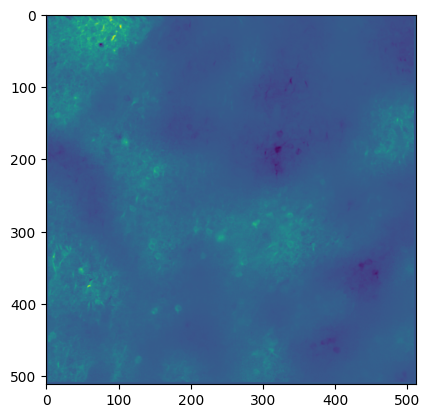

In [82]:
plt.imshow(out.reshape(512, 512).cpu())

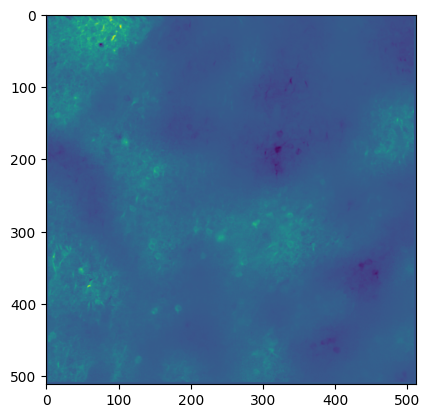

In [83]:
plt.imshow(final0.reshape(512, 512).cpu())

In [34]:
coo = u_crop.to_sparse_coo().coalesce()
rows = coo.indices()[0]  # pixel dim
cols = coo.indices()[1]  # K dim

# Sanity check - verify against a single output row
i = 0
r0_mask = rows == i
manual = (vals[r0_mask].unsqueeze(1) * product[cols[r0_mask]]).sum(0)
torch_mm = final0[i]
print(torch.allclose(manual, torch_mm, atol=1e-5))

# Also check shapes and layout
print(f"u_crop layout: {u_crop.layout}")
print(f"coo indices shape: {coo.indices().shape}")
print(f"rows range: {rows.min()} - {rows.max()}")
print(f"cols range: {cols.min()} - {cols.max()}")
print(f"u_crop shape: {u_crop.shape}")
print(f"product shape: {product.shape}")

True
u_crop layout: torch.sparse_csr
coo indices shape: torch.Size([2, 11185152])
rows range: 0 - 262143
cols range: 0 - 10922
u_crop shape: torch.Size([262144, 10923])
product shape: torch.Size([10923, 1])


In [35]:
print(torch.allclose(final0, out, atol=1e-5))  # likely True
print((final0 - out).abs().max())               # likely tiny

False
tensor(0.8449, device='cuda:0')


In [38]:
i = 192570
r_mask = rows == i
print(f"weighted[r_mask].sum(): {weighted[r_mask].sum().item():.4f}")  # should be ~0.8781
print(f"out[{i}]: {out[i].item():.4f}")
print(f"rows count for {i}: {r_mask.sum()}")
print(f"weighted shape: {weighted.shape}")
print(f"rows.unsqueeze(1).expand_as(weighted) shape: {rows.unsqueeze(1).expand_as(weighted).shape}")

weighted[r_mask].sum(): 0.0332
out[192570]: 0.0332
rows count for 192570: 42
weighted shape: torch.Size([11185152, 1])
rows.unsqueeze(1).expand_as(weighted) shape: torch.Size([11185152, 1])


In [40]:
i = 192570
r_mask = rows == i

print("via weighted:         ", weighted[r_mask].sum().item())
print("recomputed from scratch:", (vals[r_mask].unsqueeze(1) * product[cols[r_mask]]).sum().item())
print("product[cols[r_mask]] sample:", product[cols[r_mask]][:5])
print("product.shape:", product.shape)
print("product.data_ptr():", product.data_ptr())  # check if product was mutated

via weighted:          0.03321940824389458
recomputed from scratch: 0.8781125545501709
product[cols[r_mask]] sample: tensor([[-5.0338],
        [-0.7278],
        [-3.0033],
        [ 0.0963],
        [-0.7115]], device='cuda:0')
product.shape: torch.Size([10923, 1])
product.data_ptr(): 139893174759424
